In [2]:
## (ﾉ◕ヮ◕)ﾉ*:･ﾟ✧ Imports!

## Date: 2/23/2025 ಠ╭╮ಠ No Scipy. Brute for it, I guess.

# import sys
import numpy as np
import matplotlib.pyplot as plt

# Constants
h = 6.626e-34  # Planck's constant (J·s)
c = 3.0e8      # Speed of light (m/s)
k = 1.381e-23  # Boltzmann's constant (J/K)

# Filter properties
filters = {
    "B": {"lambda_0": 445e-9, "delta_lambda": 90e-9},  
    "V": {"lambda_0": 550e-9, "delta_lambda": 90e-9}   
}

In [3]:
## Functions!

# Planck's law function
def planck_law(wavelength, temperature):
    return (2.0 * h * c**2) / (wavelength**5) / (np.exp(h * c / (wavelength * k * temperature)) - 1)

# Box filter integration using the trapezoidal rule
def integrate_flux(T, lambda_0, delta_lambda, num_points=1000):
    wavelengths = np.linspace(lambda_0 - delta_lambda / 2, lambda_0 + delta_lambda / 2, num_points)
    intensities = planck_law(wavelengths, T)
    return np.trapz(intensities, wavelengths)

In [4]:
# Compute B - V for a range of temperatures
T_values = np.logspace(np.log10(4000), np.log10(25000), 20)
BV_values = []

for T in T_values:
    f_B = integrate_flux(T, filters["B"]["lambda_0"], filters["B"]["delta_lambda"])
    f_V = integrate_flux(T, filters["V"]["lambda_0"], filters["V"]["delta_lambda"])
    BV = -2.5 * np.log10(f_B / f_V)
    BV_values.append(BV)

In [5]:
# Stellar data from Carroll & Ostlie
stellar_T = np.array([30000, 9520, 7200, 6030, 5250, 3850])
stellar_BV = np.array([-0.30, -0.02, 0.30, 0.58, 0.81, 1.40])

# Normalize computed values for better alignment with real data
BV_values = np.array(BV_values)
BV_values -= BV_values[np.argmin(np.abs(T_values - 10000))]  # Calibration shift

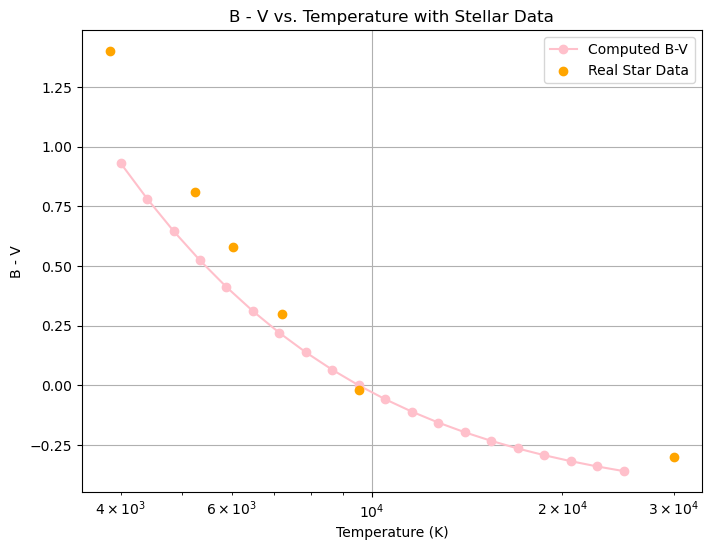

In [6]:
# Plot results
plt.figure(figsize=(8, 6))
plt.plot(T_values, BV_values, label="Computed B-V", color='pink', marker='o')
plt.scatter(stellar_T, stellar_BV, color='orange', label="Real Star Data", zorder=3)
plt.xscale("log")  
plt.xlabel("Temperature (K)")
plt.ylabel("B - V")
plt.legend()
plt.title("B - V vs. Temperature with Stellar Data")
plt.grid()
plt.show()

In [29]:
# import numpy as np
# # import matplotlib.pyplot as plt
# from scipy.integrate import simps

In [31]:
# def function_to_integrate(T):
#     return np.exp(-10000 / T)

In [33]:
# # Generate temperatures evenly spaced in log10 scale
# T_values = np.logspace(np.log10(4000), np.log10(25000), 20)
# integrals = [simps(function_to_integrate(np.linspace(4000, T, 1000)), np.linspace(4000, T, 1000)) for T in T_values]

In [35]:
# # Stellar data from Carroll & Ostlie
# spectral_types = ["B0", "A0", "F0", "G0", "K0", "M0"]
# steller_T = np.array([30000, 9520, 7200, 6030, 5250, 3850])
# steller_BV = np.array([-0.30, -0.02, 0.30, 0.58, 0.81, 1.40])

In [37]:
# # Normalize computed integral for better comparison
# integrals_scaled = np.interp(integrals, (min(integrals), max(integrals)), (min(steller_BV), max(steller_BV)))

In [39]:
# # Plot results
# plt.figure(figsize=(8, 6))
# plt.plot(T_values, integrals_scaled, label="Computed B-V (Scaled)", color='#1e5da3')
# plt.scatter(steller_T, steller_BV, color='red', label="Real Star Data")
# plt.xscale("log")  # Set x-axis to log scale
# plt.xlabel("Temperature (K)")
# plt.ylabel("B - V")
# plt.legend()
# plt.title("B - V vs. Temperature with Stellar Data")
# plt.grid()
# plt.show()